# 03 — Registration failure diagnosis (E05)

The plate-wide `registration_qc.csv` shows the phase-cross-correlation registration is broken:
~97% of shifts are **axis-locked** (one component exactly 0), magnitudes are 500–1400 px, and the
pre/post correlations are ~0.004 (essentially zero). This notebook tests the two leading causes on
the **pre-registration single-site ND2 frames**:

1. **Channel** — registration used "488nm Binned" (mNeon). Is index 2 the right channel on *every*
   day, and is 488 actually bright/structured each day (not near-empty / low-SNR)?
2. **Normalization / masking** — the pipeline only does `robust_registration_image` (percentile-clip
   + light blur). No windowing / high-pass / mask. Phase correlation then locks onto edges &
   illumination. We compare preprocessing variants and see which recovers a small, 2-D, high-
   correlation shift.

Reuses the real pipeline code (`load_nd2_cyx`, `choose_channel_index`, `robust_registration_image`)
so the diagnosis reflects exactly what the pipeline did.

In [12]:
# === Setup ===
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage.registration import phase_cross_correlation
from skimage.filters import window

_cwd = Path.cwd()
ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
sys.path.insert(0, str(ROOT))

from scripts.run_260213_longitudinal_pilot import load_nd2_cyx, choose_channel_index
from tmem_align.registration_qc import robust_registration_image, correlation
from tmem_align.register import apply_shift
from tmem_align.io import normalize_to_2d

WELL = "E05"
NUCLEAR, MCHERRY, MNEON = "405", "561", "488"   # by name; index resolved per day
MAX_READ_BYTES = 300_000_000

sel = pd.read_csv(ROOT / "reports/260213_pilot_9day/selected_pilot_files.csv")
sel = sel[sel["inferred_well"] == WELL].sort_values("inferred_day_timepoint")
DAYS = sel["inferred_day_timepoint"].tolist()
print(f"{WELL}: days {DAYS}")

# Load each day's first-site CYX exactly as the pipeline does
frames = {}   # day -> {"array": CYX, "channel_names": [...]}
for _, row in sel.iterrows():
    frames[int(row["inferred_day_timepoint"])] = load_nd2_cyx(
        Path(row["path"]), max_sites=1, max_read_bytes=MAX_READ_BYTES
    )
for d in DAYS:
    f = frames[d]
    print(f"day {d:>2}: shape={f['array'].shape}  channels={f['channel_names']}")

E05: days [8, 12, 16, 20, 25, 29, 32, 36, 39]
day  8: shape=(3, 2868, 2868)  channels=['405nm Binned', '561nm Binned', '488nm Binned']
day 12: shape=(3, 2868, 2868)  channels=['405nm Binned', '561nm Binned', '488nm Binned']
day 16: shape=(3, 2868, 2868)  channels=['405nm Binned', '561nm Binned', '488nm Binned']
day 20: shape=(3, 2868, 2868)  channels=['405nm Binned', '561nm Binned', '488nm Binned']
day 25: shape=(3, 2868, 2868)  channels=['405nm Binned', '561nm Binned', '488nm Binned']
day 29: shape=(3, 2868, 2868)  channels=['405nm Binned', '561nm Binned', '488nm Binned']
day 32: shape=(3, 2868, 2868)  channels=['405nm Binned', '561 nm', '488nm Binned']
day 36: shape=(3, 2868, 2868)  channels=['405nm Binned', '561nm Binned', '488nm Binned']
day 39: shape=(3, 2868, 2868)  channels=['405nm Binned', '561nm Binned', '488nm Binned']


## Hypothesis 1 — Channel

Confirm (a) the channel *order* is identical across days, (b) `choose_channel_index(..., '488')`
resolves to the same index every day, and (c) the 488 channel is actually bright/structured on every
day (not near-empty). A wrong index on some day, or a dim 488, produces exactly the near-zero
correlation we saw.

In [13]:
# === Per-day channel index + per-channel signal stats ===
rows = []
for d in DAYS:
    names = frames[d]["channel_names"]
    arr = frames[d]["array"]
    idx488 = choose_channel_index(names, MNEON)
    for ci, name in enumerate(names):
        ch = arr[ci].astype(np.float32)
        p1, p50, p99 = np.percentile(ch, [1, 50, 99])
        lap_var = float(gaussian_filter(ch, 1).var())  # crude focus/structure proxy
        rows.append({
            "day": d, "ch_index": ci, "name": name,
            "is_488_used": ci == idx488,
            "p1": round(p1, 1), "median": round(p50, 1), "p99": round(p99, 1),
            "dyn_range": round(p99 - p1, 1),
            "snr_p99_over_med": round(p99 / (p50 + 1e-9), 2),
        })
chan_df = pd.DataFrame(rows)
print("488 index per day:", {d: choose_channel_index(frames[d]['channel_names'], MNEON) for d in DAYS})
print("\nChannel order identical across days:",
      len({tuple(frames[d]['channel_names']) for d in DAYS}) == 1)
chan_df[chan_df["is_488_used"]]

488 index per day: {8: 2, 12: 2, 16: 2, 20: 2, 25: 2, 29: 2, 32: 2, 36: 2, 39: 2}

Channel order identical across days: False


,day,ch_index,name,is_488_used,p1,median,p99,dyn_range,snr_p99_over_med
2,8,2,488nm Binned,True,92.0,120.0,1243.0,1151.0,10.36
5,12,2,488nm Binned,True,94.0,122.0,1120.0,1026.0,9.18
8,16,2,488nm Binned,True,93.0,121.0,1268.0,1175.0,10.48
11,20,2,488nm Binned,True,92.0,120.0,1173.0,1081.0,9.77
14,25,2,488nm Binned,True,94.0,121.0,876.0,782.0,7.24
17,29,2,488nm Binned,True,92.0,120.0,1109.0,1017.0,9.24
20,32,2,488nm Binned,True,93.0,120.0,953.0,860.0,7.94
23,36,2,488nm Binned,True,93.0,121.0,912.0,819.0,7.54
26,39,2,488nm Binned,True,91.0,119.0,781.0,690.0,6.56


In [14]:
# Full per-channel table (all channels, all days)
chan_df

,day,ch_index,name,is_488_used,p1,median,p99,dyn_range,snr_p99_over_med
0,8,0,405nm Binned,False,93.0,121.0,196.0,103.0,1.62
1,8,1,561nm Binned,False,80.0,102.0,174.0,94.0,1.71
2,8,2,488nm Binned,True,92.0,120.0,1243.0,1151.0,10.36
3,12,0,405nm Binned,False,91.0,118.0,170.0,79.0,1.44
4,12,1,561nm Binned,False,81.0,103.0,172.0,91.0,1.67
5,12,2,488nm Binned,True,94.0,122.0,1120.0,1026.0,9.18
6,16,0,405nm Binned,False,92.0,119.0,171.0,79.0,1.44
7,16,1,561nm Binned,False,80.0,102.0,230.0,150.0,2.25
8,16,2,488nm Binned,True,93.0,121.0,1268.0,1175.0,10.48
9,20,0,405nm Binned,False,91.0,119.0,173.0,82.0,1.45


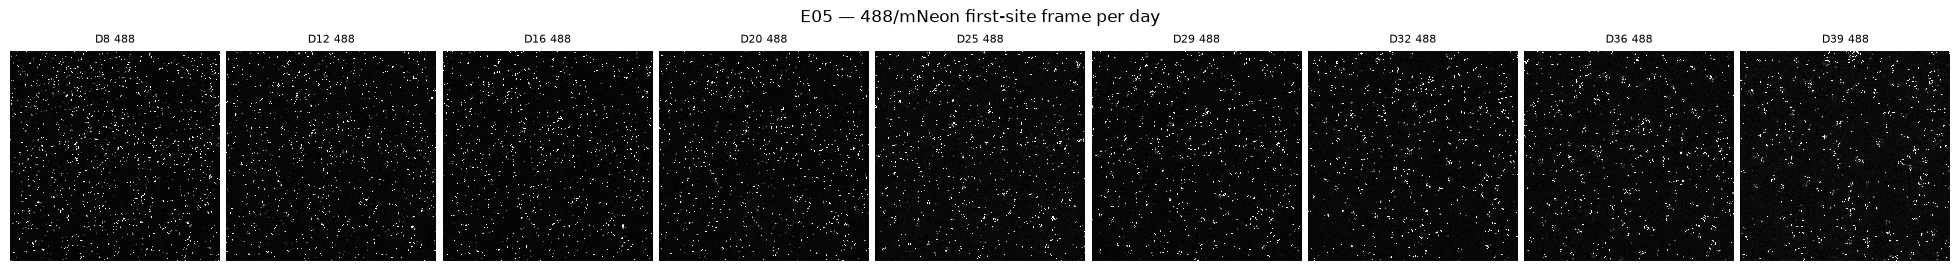

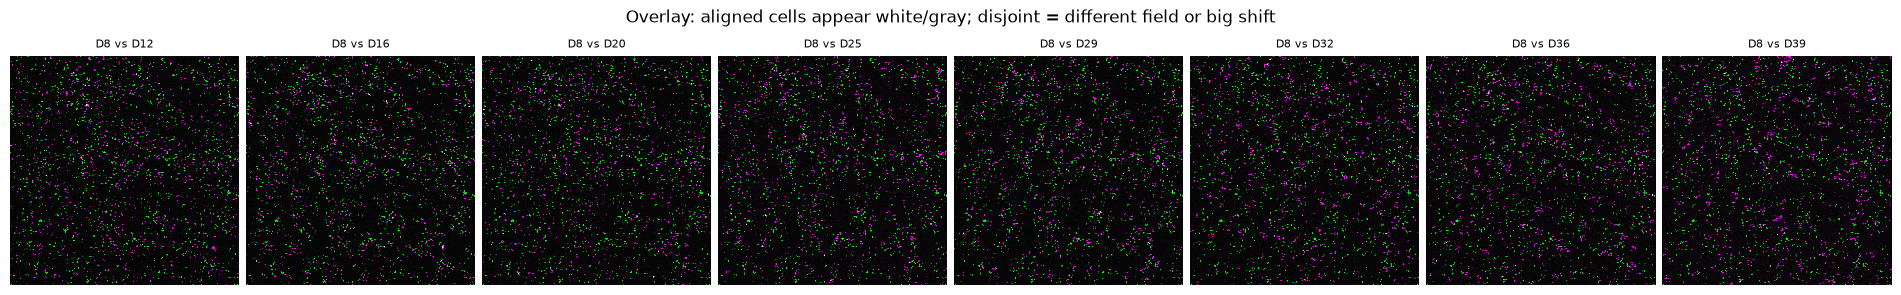

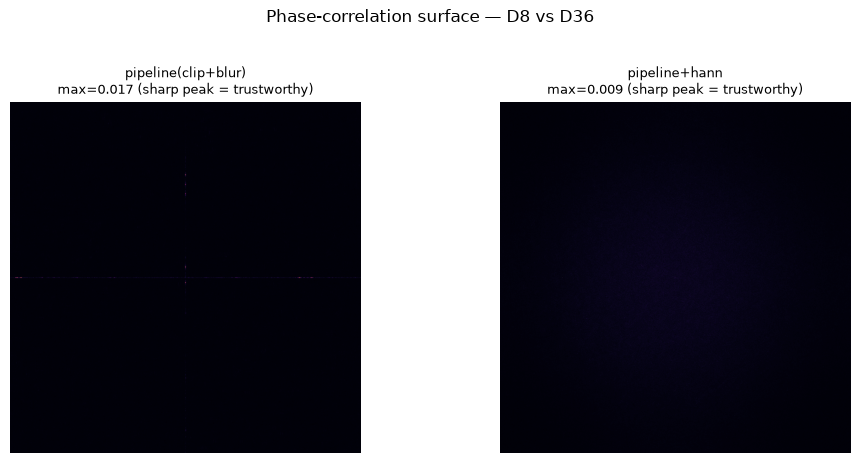

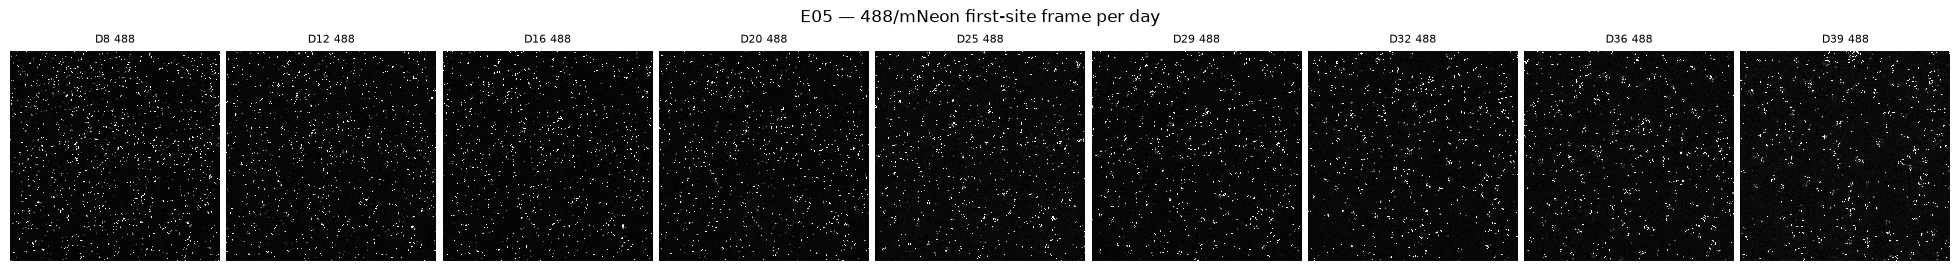

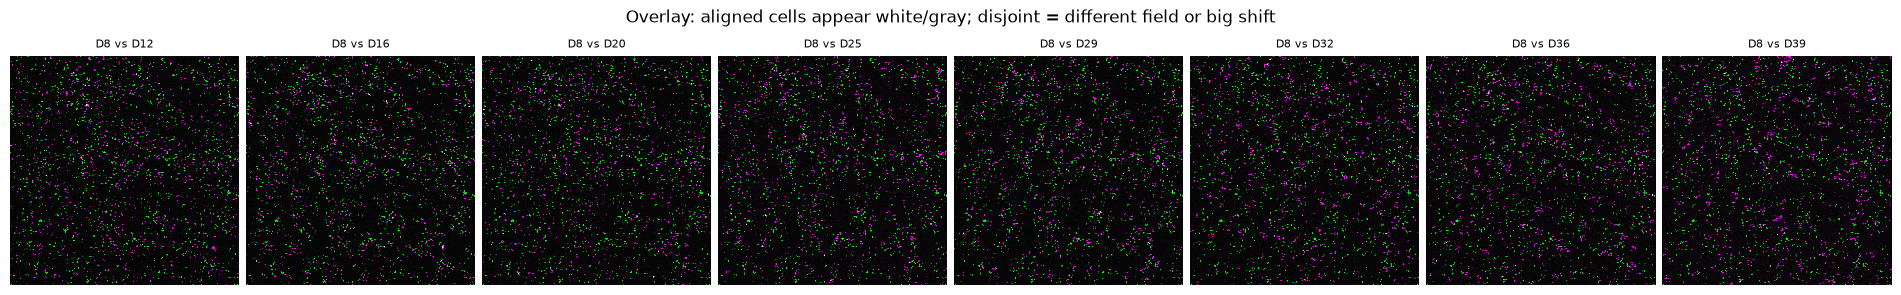

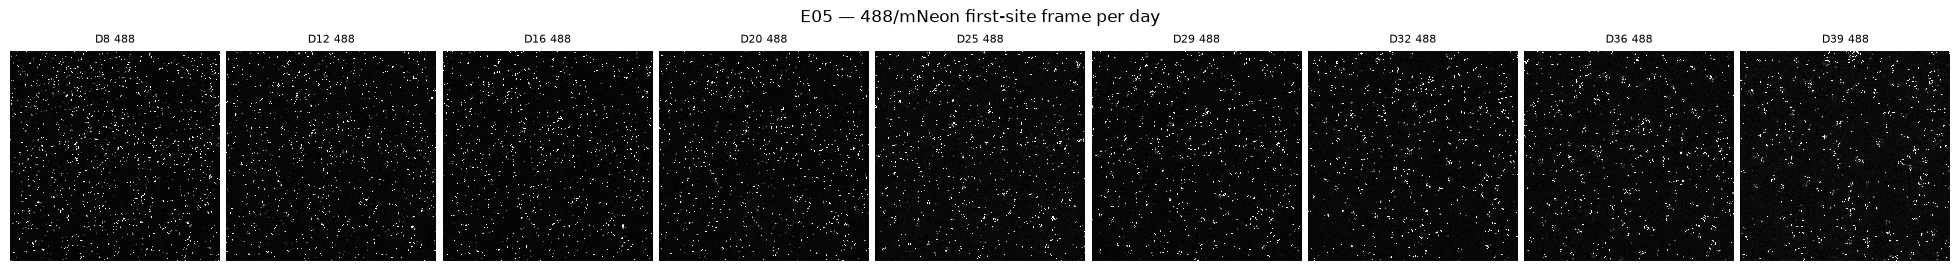

In [15]:

# === 488 montage across days: same field? real structure? ===
def clip01(img, lo=1, hi=99):
    a, b = np.percentile(img, [lo, hi])
    return np.clip((img.astype(float) - a) / (b - a + 1e-9), 0, 1)

n = len(DAYS)
fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.6))
for ax, d in zip(axes, DAYS):
    idx = choose_channel_index(frames[d]["channel_names"], MNEON)
    ax.imshow(clip01(frames[d]["array"][idx]), cmap="gray", interpolation="nearest")
    ax.set_title(f"D{d} 488", fontsize=8)
    ax.axis("off")
fig.suptitle(f"{WELL} — 488/mNeon first-site frame per day", y=1.02)
fig.subplots_adjust(left=0.01, right=0.99, top=0.9, bottom=0.01, wspace=0.03)


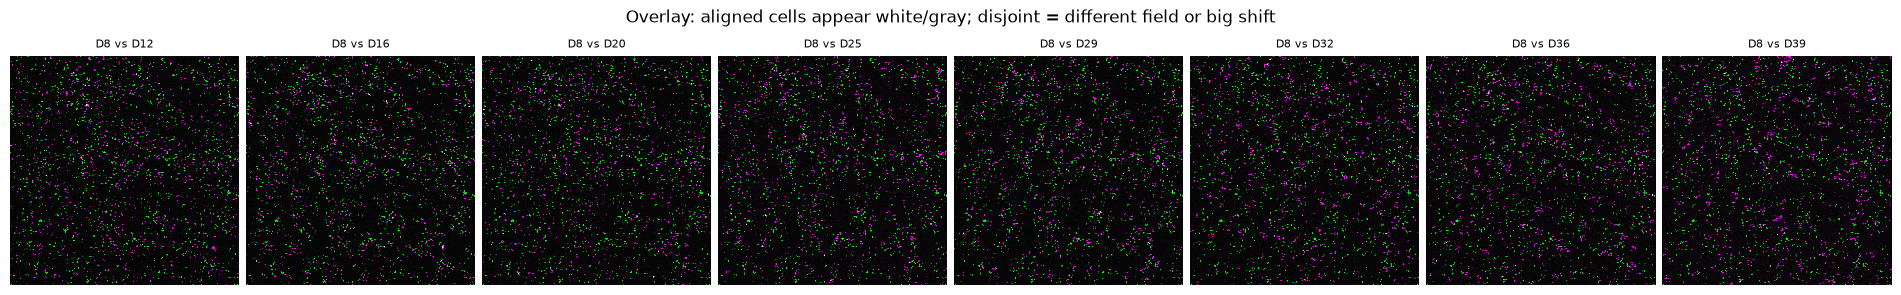

In [16]:

# === Same-field check: overlay day 8 (green) vs each later day (magenta), raw 488 ===
ref_day = DAYS[0]
ref_idx = choose_channel_index(frames[ref_day]["channel_names"], MNEON)
ref488 = clip01(frames[ref_day]["array"][ref_idx])
others = DAYS[1:]
fig, axes = plt.subplots(1, len(others), figsize=(2.4 * len(others), 2.8))
for ax, d in zip(axes, others):
    idx = choose_channel_index(frames[d]["channel_names"], MNEON)
    mov = clip01(frames[d]["array"][idx])
    rgb = np.zeros((*ref488.shape, 3), np.float32)
    rgb[..., 1] = ref488      # green = day 8 reference
    rgb[..., 0] = mov         # magenta = this day
    rgb[..., 2] = mov
    ax.imshow(rgb, interpolation="nearest")
    ax.set_title(f"D{ref_day} vs D{d}", fontsize=8)
    ax.axis("off")
fig.suptitle("Overlay: aligned cells appear white/gray; disjoint = different field or big shift", y=1.02)
fig.subplots_adjust(left=0.01, right=0.99, top=0.88, bottom=0.01, wspace=0.03)


## Hypothesis 2 — Normalization / masking

The pipeline preprocesses with `robust_registration_image` only. Phase correlation is very sensitive
to image borders and low-frequency illumination — a **Hann window** and/or **high-pass** usually fix
axis-locked garbage. We run several variants and, for each, report the estimated `(dy, dx)`, whether
it is axis-locked, and the **post-shift Pearson correlation on the raw frames** (a fair, variant-
independent quality score). A good variant gives a small, 2-D shift with clearly higher correlation.

In [17]:
# === Preprocessing variants (frame -> processed 2D float) ===
def v_raw(f):
    return normalize_to_2d(f).astype(np.float32)

def v_pipeline(f):                      # what the pipeline actually uses
    return robust_registration_image(f)

def v_highpass(f):                      # remove illumination gradient
    a = normalize_to_2d(f).astype(np.float32)
    return a - gaussian_filter(a, sigma=30)

def v_window(f):                        # pipeline preprocess + Hann window (kills edge wraparound)
    a = robust_registration_image(f)
    return a * window("hann", a.shape)

def v_highpass_window(f):
    a = v_highpass(f)
    return a * window("hann", a.shape)

VARIANTS = {
    "raw": v_raw,
    "pipeline(clip+blur)": v_pipeline,
    "highpass": v_highpass,
    "pipeline+hann": v_window,
    "highpass+hann": v_highpass_window,
}

def eval_variant(ref_raw, mov_raw, fn):
    rp, mp = fn(ref_raw), fn(mov_raw)
    shift, _, _ = phase_cross_correlation(rp, mp, upsample_factor=10)
    dy, dx = float(shift[0]), float(shift[1])
    shifted = apply_shift(normalize_to_2d(mov_raw).astype(np.float32), dy, dx)
    post = correlation(normalize_to_2d(ref_raw).astype(np.float32), shifted)
    axis_locked = (abs(dy) < 1e-6) ^ (abs(dx) < 1e-6)
    return {"dy": round(dy, 1), "dx": round(dx, 1),
            "shift_mag": round(float(np.hypot(dy, dx)), 1),
            "axis_locked": axis_locked, "post_corr": round(post, 4)}

def masked_row(ref_raw, mov_raw, thresh_pct=20):
    r = normalize_to_2d(ref_raw).astype(np.float32)
    m = normalize_to_2d(mov_raw).astype(np.float32)
    rmask = r > np.percentile(r, thresh_pct)
    mmask = m > np.percentile(m, thresh_pct)
    # masked phase correlation returns just the shift (older skimage) or a 3-tuple (newer)
    result = phase_cross_correlation(r, m, reference_mask=rmask, moving_mask=mmask)
    shift = np.asarray(result[0] if isinstance(result, tuple) else result).ravel()
    dy, dx = float(shift[0]), float(shift[1])
    shifted = apply_shift(m, dy, dx)
    return {"dy": round(dy, 1), "dx": round(dx, 1),
            "shift_mag": round(float(np.hypot(dy, dx)), 1),
            "axis_locked": (abs(dy) < 1e-6) ^ (abs(dx) < 1e-6),
            "post_corr": round(correlation(r, shifted), 4)}

print("variants:", list(VARIANTS) + ["masked"])

variants: ['raw', 'pipeline(clip+blur)', 'highpass', 'pipeline+hann', 'highpass+hann', 'masked']


In [18]:
# === Focus on the worst day for E05 (day 36: pipeline reported dx=-1374.8) ===
def frame_488(d):
    idx = choose_channel_index(frames[d]["channel_names"], MNEON)
    return frames[d]["array"][idx]

bad_day = 36 if 36 in DAYS else DAYS[-1]
ref_raw = frame_488(DAYS[0])
mov_raw = frame_488(bad_day)

rows = [{"variant": name, **eval_variant(ref_raw, mov_raw, fn)} for name, fn in VARIANTS.items()]
rows.append({"variant": "masked", **masked_row(ref_raw, mov_raw)})
print(f"Reference day {DAYS[0]}  vs  day {bad_day}")
print("(pipeline row should reproduce the QC csv's garbage shift)")
pd.DataFrame(rows)

Reference day 8  vs  day 36
(pipeline row should reproduce the QC csv's garbage shift)


,variant,dy,dx,shift_mag,axis_locked,post_corr
0,raw,-0.2,-0.1,0.2,False,0.0085
1,pipeline(clip+blur),0.0,-1374.8,1374.8,True,0.0042
2,highpass,920.8,-0.1,920.8,False,-0.0071
3,pipeline+hann,-1.0,-1.0,1.4,False,0.0079
4,highpass+hann,-0.9,-0.9,1.3,False,0.0080
5,masked,-32.0,-150.0,153.4,False,0.0421


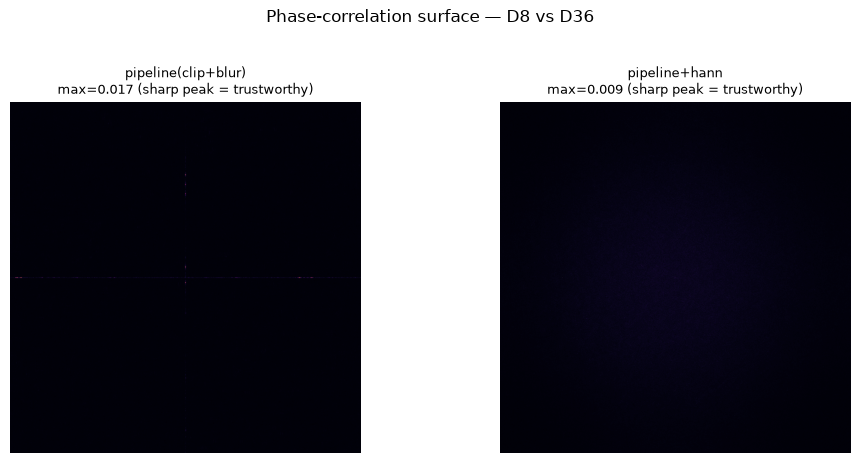

In [19]:

# === Phase-correlation surface: sharp single peak (good) vs diffuse/edge (bad) ===
def phase_surface(a, b):
    A, B = np.fft.fft2(a), np.fft.fft2(b)
    R = A * np.conj(B)
    R /= np.abs(R) + 1e-9
    return np.fft.fftshift(np.abs(np.fft.ifft2(R)))

pairs = [("pipeline(clip+blur)", v_pipeline), ("pipeline+hann", v_window)]
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4.5))
for ax, (name, fn) in zip(axes, pairs):
    surf = phase_surface(fn(ref_raw), fn(mov_raw))
    ax.imshow(surf, cmap="inferno")
    ax.set_title(f"{name}\nmax={surf.max():.3f} (sharp peak = trustworthy)", fontsize=9)
    ax.axis("off")
fig.suptitle(f"Phase-correlation surface — D{DAYS[0]} vs D{bad_day}", y=1.02)
fig.tight_layout()


In [20]:
# === All days x variants: which preprocessing gives sane, high-correlation shifts? ===
ref488 = frame_488(DAYS[0])
records = []
for d in DAYS[1:]:
    mov = frame_488(d)
    for name, fn in VARIANTS.items():
        records.append({"day": d, "variant": name, **eval_variant(ref488, mov, fn)})
    records.append({"day": d, "variant": "masked", **masked_row(ref488, mov)})
res = pd.DataFrame(records)

print("Median post-shift correlation by variant (higher = better):")
print(res.groupby("variant")["post_corr"].median().sort_values(ascending=False).to_string())
print("\nAxis-locked fraction by variant (lower = better):")
print(res.groupby("variant")["axis_locked"].mean().sort_values().to_string())

pivot = res.pivot(index="day", columns="variant", values="post_corr")
pivot

Median post-shift correlation by variant (higher = better):
variant
masked                 0.08875
pipeline(clip+blur)    0.00700
highpass+hann          0.00485
pipeline+hann          0.00480
raw                    0.00360
highpass               0.00260

Axis-locked fraction by variant (lower = better):
variant
highpass               0.125
masked                 0.125
raw                    0.125
highpass+hann          0.625
pipeline+hann          0.750
pipeline(clip+blur)    1.000


variant,highpass,highpass+hann,masked,pipeline(clip+blur),pipeline+hann,raw
day,,,,,,
12,0.0028,0.0028,0.1625,0.0049,0.0028,0.0028
16,0.0181,0.0179,0.1428,0.0071,0.0179,0.0181
20,0.0007,0.0026,0.1157,0.0094,0.0026,0.0028
25,0.0044,0.0045,0.0906,0.0060,0.0044,0.0044
29,-0.0009,0.0086,0.0869,0.0297,0.0086,-0.0009
32,0.0024,-0.0017,0.0487,0.0069,-0.0017,0.0024
36,-0.0071,0.0080,0.0421,0.0042,0.0079,0.0085
39,0.0053,0.0052,0.0316,0.0094,0.0052,0.0053


## How to read this

- **Hypothesis 1 (channel):** if the 488 index is 2 on every day, the channel order is identical, and
  the 488 stats show real dynamic range on every day (and the montage shows the same field with
  structure), the channel is *not* the primary cause — attention moves to preprocessing / whether the
  first site is the same field.
- **Hypothesis 2 (normalization):** compare `post_corr` and `axis_locked` across variants. If
  `pipeline(clip+blur)` reproduces the garbage (axis-locked, corr ~0) but `pipeline+hann` /
  `highpass+hann` / `masked` yield small 2-D shifts with clearly higher correlation and sharp phase
  peaks, the fix is preprocessing — add windowing/high-pass (and optionally masking) in
  `robust_registration_image` / `register_translation`.
- If **no** variant recovers a high correlation and the overlay shows disjoint fields, the first
  site is a different physical location across days — the problem is upstream site selection in
  `load_nd2_cyx`, not preprocessing.